In [ ]:
import os
os.environ["PATH"] = os.path.expanduser("~/texlive/bin/x86_64-linux") + ":" + os.environ["PATH"]

import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import scienceplots

from hmf import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

### Halo mass function

In [21]:
def get_HMF(mass, box_length, dlog=0.2, log_mass_bins=None, mask_zeros=True):
    """
    Calculate the halo mass function defined as the number of haloes per
    logarithmic mass interval `dlog` per volume.

    Unless `log_mass_bins` is provided, the mass bins are created from
    `log_mass.min()` to `log_mass.max()` with a step of `dlog`.
    """
    if mask_zeros:
        mass = mass[mass > 0]

    log_mass = np.log10(mass)
    if log_mass_bins is None:
        bins = np.arange(log_mass.min(), log_mass.max() + dlog, dlog)
    else:
        bins = log_mass_bins

    xrange = (bins.min(), bins.max())
    counts, _ = np.histogram(log_mass, bins=bins, range=xrange)
    counts = counts.astype(float)

    volume = box_length**3

    counts /= volume * dlog
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, counts


from colossus.cosmology import cosmology
from colossus.lss import mass_function

cosmo_params={'flat': True, 'H0': 68.11, 'Om0': 0.306,
              'Ob0': 0.0486, 'sigma8': 0.8213, 'ns': 0.967}

# Next, get the HMF from colossus and create its interpolant.
cosmology.addCosmology("myCosmo", **cosmo_params)
cosmology.setCosmology("myCosmo")

x_theory = np.logspace(11., 15., 10000)
y_theory = mass_function.massFunction(
    x_theory, 0.0, mdef="fof", model="angulo12", q_out="dndlnM",) * np.log(10)
y_theory_rockstar = mass_function.massFunction(
    x_theory, 0.0, mdef="200c", model="tinker08", q_out="dndlnM",) * np.log(10)

In [8]:
nsnap = "130"
f = f"/mnt/home/rstiskalek/ceph/CSiBORG/RANDOM_N512_L300/step_0/output/groups_{nsnap}/fof_subhalo_tab_{nsnap}.hdf5"
reader = csiborgtools.read.CSiBORGCatalogue(0, 0, paths, fpath_override=f, boxsize=300)

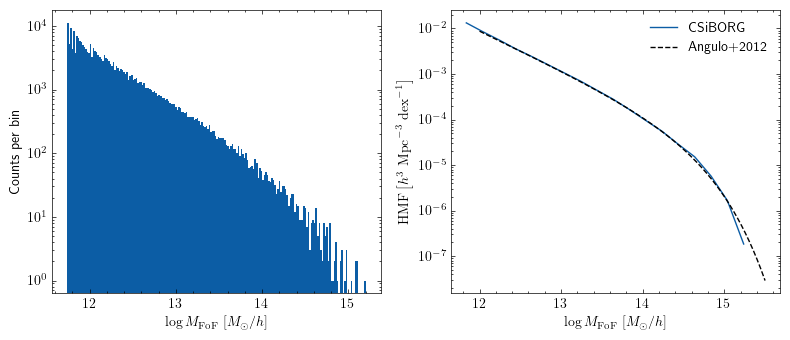

In [13]:
M = reader["totmass"]
M = M[M > 1e11]

x, y = get_HMF(M, box_length=300, dlog=0.2)

with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
    axs[0].hist(np.log10(M), bins="auto")
    axs[0].set_yscale("log")
    axs[0].set_xlabel(r"$\log M_{\mathrm{FoF}}~[M_\odot / h]$")
    axs[0].set_ylabel(r"Counts per bin")
    
    axs[1].plot(x, y, label=r"CSiBORG")
    axs[1].plot(np.log10(x_theory), y_theory, label=r"Angulo+2012", linestyle="--", 
                color="black")

    axs[1].set_yscale("log")
    axs[1].set_xlabel(r"$\log M_{\mathrm{FoF}}~[M_\odot / h]$")
    axs[1].set_ylabel(r"$\mathrm{HMF} \left[ h^3~\mathrm{Mpc}^{-3}~\mathrm{dex}^{-1} \right]$")
    axs[1].legend()

    fig.tight_layout()
    # fig.savefig("HMF_FOF.png", dpi=300)
    fig.show()

In [27]:
reader_rockstar = csiborgtools.read.ReaderRockstar(
    "/mnt/home/rstiskalek/ceph/CSiBORG/RANDOM_N512_L300/step_1/output/Rockstar/", 130)

Mvir = reader_rockstar["M200c"]
m_rock = (Mvir > 1e11) & (Mvir < 1e15)

Reading a Rockstar catalogue from `/mnt/home/rstiskalek/ceph/CSiBORG/RANDOM_N512_L300/step_1/output/Rockstar/out_130.list`.


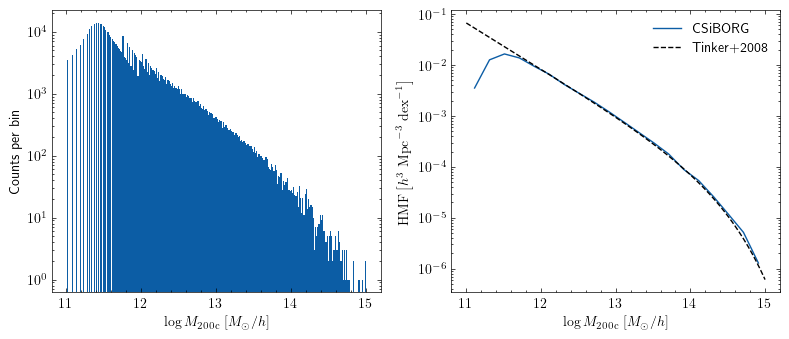

In [28]:
x, y = get_HMF(Mvir[m_rock], box_length=300, dlog=0.2)

with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
    axs[0].hist(np.log10(Mvir[m_rock]), bins="auto")
    axs[0].set_yscale("log")
    axs[0].set_xlabel(r"$\log M_{\mathrm{200c}}~[M_\odot / h]$")
    axs[0].set_ylabel(r"Counts per bin")

    axs[1].plot(x, y, label=r"CSiBORG")
    axs[1].plot(np.log10(x_theory), y_theory_rockstar, label=r"Tinker+2008", linestyle="--", 
                color="black")

    axs[1].set_yscale("log")
    axs[1].set_xlabel(r"$\log M_{\mathrm{200c}}~[M_\odot / h]$")
    axs[1].set_ylabel(r"$\mathrm{HMF} \left[ h^3~\mathrm{Mpc}^{-3}~\mathrm{dex}^{-1} \right]$")
    axs[1].legend()

    fig.tight_layout()
    fig.savefig("HMF_rockstar.png", dpi=300)
    fig.show()

### Check Virgo is present

In [2]:
m = reader["totmass"] > 1e12

prob_match = csiborgtools.match.MatchingProbability(reader["cartesian_pos"][m], np.log10(reader["totmass"][m]),)

cl = csiborgtools.clusters["Virgo"]
ref_pos = cl.cartesian_pos(reader.boxsize)
ref_log_mass = 14.5
cdf, indxs = prob_match.match_halo(ref_pos, ref_log_mass, verbose=True)
cdf, indxs

pos_virgo = reader["cartesian_pos"][m][indxs]

NameError: name 'reader' is not defined

### Make a cutout around Virgo cluster

In [3]:
reader_snapshot = csiborgtools.read.CSiBORGSnapshot(
    0, 0, paths, fpath_override="/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/resimulations/step_4/output/snapdir_130/snapshot_130.hdf5")

pos = reader_snapshot.coordinates()
mass = reader_snapshot.masses()

2025-04-06 22:36:04,672 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [01:00<00:00,  1.88s/it]


2025-04-06 22:37:07,742 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [00:14<00:00,  2.27it/s]


In [4]:
# boxsize = 340.5
boxsize = 681.
pos_virgo = [boxsize / 2, boxsize / 2, boxsize / 2]
mask_width = 50

mask_box = csiborgtools.read.find_boxed(pos, pos_virgo, mask_width, boxsize)

In [9]:
pos_box = pos[mask_box]
mass_box = mass[mask_box]
pos_box -= np.min(pos_box, axis=0)

density_obj = csiborgtools.field.DensityField(mask_width, "TSC")
rho = density_obj.density_2d(pos_box, mass_box, 2, grid=2048, verbose=True)



Using TSC mass assignment scheme with weights
Time taken = 0.181 seconds



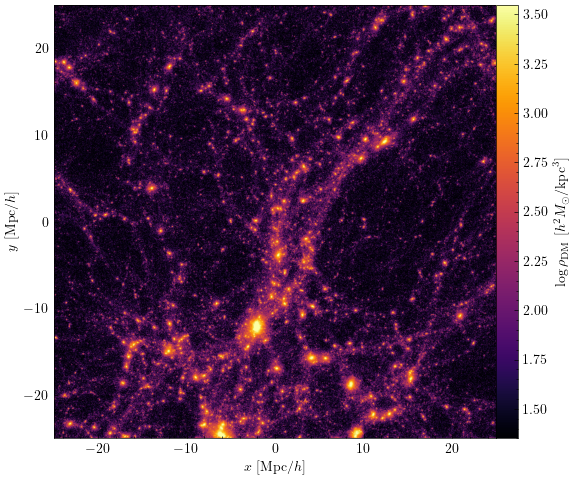

In [15]:
extent = (-mask_width / 2, mask_width / 2, -mask_width / 2, mask_width / 2)
# img = rho
img = np.log10(1 + rho)

vmin = 1.35
vmax = np.percentile(img.flatten(), 99.9)

with plt.style.context("science"):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, extent=extent, origin="lower", aspect="auto",
               cmap="inferno", vmin=vmin, vmax=vmax)
    plt.colorbar(label=r"$\log \rho_{\rm DM} ~ [h^2 M_\odot / \mathrm{kpc}^3]$", pad=0)
    plt.xlabel(r"$x ~ [\mathrm{Mpc} / h]$")
    plt.ylabel(r"$y ~ [\mathrm{Mpc} / h]$")


    plt.tight_layout()
    plt.savefig("density_box_lower_res.png", dpi=500)
    plt.show()